In [3]:
from inspect_ai.log import read_eval_log
import csv
import os
from typing import Dict, List, Any
import pandas as pd
import logging
from pathlib import Path
from utils_consistency.metrics import (
    negation_frequentist_metric,
    or_frequentist_metric,
    and_frequentist_metric, 
    consequence_frequentist_metric, 
    paraphrase_frequentist_metric, 
    but_frequentist_metric, 
    cond_frequentist_metric,
    andor_frequentist_metric, 
    expevidence_frequentist_metric
)
import matplotlib.pyplot as plt


In [4]:
log_path = "2025-01-05T18-27-01+05-30_initial-consistency_3f8K9pe7m7TXieyh4yodUe.eval"
eval_log = read_eval_log(log_path)
sample = eval_log.samples[0]
samples = eval_log.samples

In [5]:
sample.dict().keys()

/var/folders/0z/98hl6yf107q35dj2790zq94h0000gn/T/ipykernel_2348/1816351524.py:1: PydanticDeprecatedSince20: The `dict` method is deprecated; use `model_dump` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.10/migration/
  sample.dict().keys()


dict_keys(['id', 'epoch', 'input', 'choices', 'target', 'sandbox', 'files', 'setup', 'messages', 'output', 'scores', 'metadata', 'store', 'events', 'model_usage', 'error', 'attachments'])

In [6]:
sample.metadata.get('consistency_checks', {})

{'expevidence': {'P': {'title': 'Will Glenn Youngkin be the Republican nominee for the 2024 US Presidential Election?',
   'body': 'This question will resolve as **Yes** if Glenn Youngkin is selected by the Republican National Convention as the nominee for the 2024 US Presidential Election. All other candidates will resolve as **No**. This question is not restricted to the candidates currently listed; other options may be added in the future.\n\nFor this question, it is not relevant who receives the Republican nomination on the day of the 2024 US election; it is solely determined by who is selected by the delegates of the [Republican National Convention](https://en.wikipedia.org/wiki/Republican_National_Convention).',
   'forecast': 0.1,
   'forecast_reasoning': 'Reasoning: As of the latest information available, Glenn Youngkin, the Governor of Virginia, has not officially announced his candidacy for the 2024 Republican presidential nomination. The current field of potential candidates

# Helper functions

In [7]:
import pandas as pd
import numpy as np

# Define the mapping with standardized check keys
consistency_checks_mapping = {
    'expevidence': ["P", "Q", "R", "S"],
    'andor': ["P", "Q", "R", "S"],
    'but': ["P", "Q", "R"],
    'cond': ["P", "Q", "R"],
    'consequence': ["P", "Q"],
    'paraphrase': ["P", "Q"],
    'and': ["P", "Q", "R"],
    'or': ["P", "Q", "R"],
    'not': ["P", "Q"]
}
def convert_samples_to_wide_df(samples, consistency_checks_mapping):
    """
    Convert a list of samples into a wide-format pandas DataFrame.
    
    Parameters:
    - samples (list): List of sample objects with attributes 'id' and 'metadata'.
    - consistency_checks_mapping (dict): Mapping of consistency types to their checks.
    
    Returns:
    - pd.DataFrame: Wide-format DataFrame with one row per sample.
    """
    data = []
    
    for sample in samples:
        sample_id = sample.id
        metadata = sample.metadata
        consistency_type = metadata.get('consistency_type')
        consistency_checks = metadata.get('consistency_checks', {}).get(consistency_type, {})
        
        # Initialize a dictionary for the sample
        sample_dict = {
            'sample_id': sample_id,
            'consistency_type': consistency_type
        }
        
        # Get the list of expected checks for this consistency type
        expected_checks = consistency_checks_mapping.get(consistency_type, [])
        
        for idx, check_key in enumerate(expected_checks):
            # Assign standardized keys P, Q, R, S based on order
            standardized_key = ['P', 'Q', 'R', 'S'][idx] if idx < 4 else f'Check_{idx+1}'
            
            check_data = consistency_checks.get(check_key, {})
            if not check_data:
                # If the check is missing, assign NaN
                sample_dict[f'{standardized_key}_title'] = np.nan
                sample_dict[f'{standardized_key}_body'] = np.nan
                sample_dict[f'{standardized_key}_forecast'] = np.nan
                continue
            
            # Extract fields, handling missing fields gracefully
            title = check_data.get('title', np.nan)
            body = check_data.get('body', np.nan)
            forecast = check_data.get('forecast', np.nan)
            
            # Assign to standardized columns
            sample_dict[f'{standardized_key}_title'] = title
            sample_dict[f'{standardized_key}_body'] = body
            sample_dict[f'{standardized_key}_forecast'] = forecast
        
        data.append(sample_dict)
    
    # Create DataFrame
    df = pd.DataFrame(data)
    return df



In [8]:
def process_first_eval_sample(log_path: str) -> str:
    """
    Process the first eval sample from a log file and convert it to CSV format.
    
    Args:
        log_path: Path to the eval log file
    
    Returns:
        str: Path to the generated CSV file
    """
    # Read the log file using read_eval_log
    eval_log = read_eval_log(log_path)
    if not eval_log.samples:
        raise ValueError("No samples found in eval log")
    
    # Get first sample
    sample = eval_log.samples[0]
    consistency_checks = sample.metadata.get('consistency_checks', {})
    
    # Prepare CSV data
    csv_rows = []
    headers = ['check_type', 'P_title', 'P_forecast', 'Q_title', 'Q_forecast', 'R_title', 'R_forecast', 'score']
    
    # Process each type of consistency check
    for check_type, checks in consistency_checks.items():
        if not isinstance(checks, list):
            continue
            
        for check in checks:
            row = {
                'check_type': check_type,
                'P_title': check['P'].get('title', ''),
                'P_forecast': check['P'].get('forecast', ''),
                'Q_title': check['Q'].get('title', ''),
                'Q_forecast': check['Q'].get('forecast', ''),
                'R_title': check.get('R', {}).get('title', ''),
                'R_forecast': check.get('R', {}).get('forecast', ''),
                'score': check.get('score', '')
            }
            csv_rows.append(row)
    
    # Generate output filename
    output_dir = os.path.dirname(log_path)
    base_name = os.path.splitext(os.path.basename(log_path))[0]
    output_path = os.path.join(output_dir, f"{base_name}_processed.csv")
    
    # Write to CSV
    with open(output_path, 'w', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=headers)
        writer.writeheader()
        writer.writerows(csv_rows)
    
    return output_path



def process_eval_logs_to_csv(log_path: str, output_path: str) -> None:
    """Process evaluation logs and store P and Q questions in a CSV file."""
    try:
        eval_log = read_eval_log(log_path)
        processed_data = []
        
        for sample in eval_log.samples:
            if 'question_p' in sample.metadata and 'question_q' in sample.metadata:
                p = sample.metadata['question_p']
                q = sample.metadata['question_q']
                
                entry = {
                    'p_title': p.get('title', ''),
                    'p_body': p.get('body', ''),
                    'q_title': q.get('title', ''),
                    'q_body': q.get('body', '')
                }
                processed_data.append(entry)
        
        df = pd.DataFrame(processed_data)
        df.to_csv(output_path, index=False)
        print(f"Processed {len(df)} question pairs to {output_path}")
        
    except Exception as e:
        logging.error(f"Error processing eval logs: {str(e)}")
        raise

# Define the logs directory
logs_dir = "/Users/bprithvi/Desktop/Research Projects/Brachio/adaptive_evals/logs/gpt-4o_consistency_logs"


log_paths = list(Path(logs_dir).glob("*.eval"))  # Gets all .eval files
csv_paths = []

for path in log_paths:  # or log_files or eval_files
    csv_path = process_first_eval_sample(path)
    csv_paths.append(csv_path)

adaptive_combined_df = pd.concat([pd.read_csv(path) for path in csv_paths], 
                       axis=0, 
                       ignore_index=True)

adaptive_combined_df.rename(columns={'check_type': 'consistency_type', 'score': 'frequentist_score'}, inplace=True)


#Initial
# if __name__ == "__main__":
#     process_eval_logs_to_csv("logs/2024-12-31T20-20-44+05-30_initial-consistency_CtRhvzAAkDnGJgXJ868DUB.eval", "questions.csv")

#Adaptive
# if __name__ == "__main__":
#     log_path = "logs/2024-12-31T21-37-28+05-30_adaptive-consistency_BbjyeXVd9TxMMNVoMUGYuR.eval"
#     try:
#         csv_path = process_first_eval_sample(log_path)
#         print(f"Successfully created CSV at: {csv_path}")
#     except Exception as e:
#         print(f"Error processing log: {str(e)}")

### Random Baseline

In [9]:
random_logs_dir = "/Users/bprithvi/Desktop/Research Projects/Brachio/adaptive_evals/logs/gpt-4o_random_consistency_logs"


random_log_paths = list(Path(random_logs_dir).glob("*.eval"))  # Gets all .eval files
random_csv_paths = []

for path in random_log_paths:  # or log_files or eval_files
    random_csv_path = process_first_eval_sample(path)
    random_csv_paths.append(random_csv_path)

random_combined_df = pd.concat([pd.read_csv(path) for path in random_csv_paths], 
                       axis=0, 
                       ignore_index=True)

random_combined_df.rename(columns={'check_type': 'consistency_type', 'score': 'frequentist_score'}, inplace=True)


/var/folders/0z/98hl6yf107q35dj2790zq94h0000gn/T/ipykernel_2348/1796584481.py:11: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  random_combined_df = pd.concat([pd.read_csv(path) for path in random_csv_paths],


In [10]:
random_combined_df.head(3)

,consistency_type,P_title,P_forecast,Q_title,Q_forecast,R_title,R_forecast,frequentist_score
0,expevidence,Will FC Barcelona win the 2025 UEFA Champions ...,0.15,Will Real Madrid reach the semifinals of the 2...,0.65,Given that Real Madrid reaches the semifinals ...,0.35,0.330091
1,expevidence,"Will Bitcoin's price exceed $100,000 by Decemb...",0.35,"Will Ethereum's price exceed $10,000 by Decemb...",0.35,"Given that Ethereum's price exceeds $10,000 by...",0.75,0.566365
2,expevidence,Will Taylor Swift release a new album by June ...,0.75,Will Beyoncé announce a new world tour in 2025?,0.65,Given that Beyoncé announces a new world tour ...,0.65,0.053939


### Initial Consistency

In [11]:
# Convert the samples to a wide-format DataFrame
df_wide = convert_samples_to_wide_df(samples, consistency_checks_mapping)

# Display the DataFrame
df_wide.head(3)

,sample_id,consistency_type,P_title,P_body,P_forecast,Q_title,Q_body,Q_forecast,R_title,R_body,R_forecast,S_title,S_body,S_forecast
0,1,expevidence,Will Glenn Youngkin be the Republican nominee ...,This question will resolve as **Yes** if Glenn...,0.10,Will Larry Elder be the Republican nominee for...,This question will resolve as **Yes** if Larry...,0.02,"Given Larry Elder is the Republican nominee, w...",Suppose the following is true: Larry Elder is ...,0.00,Given that Larry Elder is not the Republican n...,Suppose the following is true: Larry Elder is ...,0.10
1,2,expevidence,[Metaculus] Will Joe Biden announce before Jul...,"Will Joe Biden announce before July 15, 2024 t...",0.15,Will Kamala's odds of winning increase over th...,Resolves YES if the Electoral College probabil...,0.45,Conditional on Kamala's odds of winning increa...,Suppose the following is true: Kamala Harris's...,0.15,Given Kamala's odds of winning do not increase...,Suppose the following is true: Kamala's odds o...,0.15
2,3,expevidence,Will Nikki Haley be the Republican nominee for...,This question will resolve as **Yes** if Nikki...,0.15,Will Donald Trump be the Republican nominee fo...,This question will resolve as **Yes** if Donal...,0.75,Conditional on Donald Trump being the Republic...,This question explores the scenario where Dona...,0.00,"If Donald Trump is not the Republican nominee,...",Suppose Donald Trump is not selected by the Re...,0.25


In [13]:
# Mapping from consistency_type to the corresponding metric function
consistency_type_to_metric = {
    'expevidence': expevidence_frequentist_metric,
    'andor': andor_frequentist_metric,
    'but': but_frequentist_metric,
    'cond': cond_frequentist_metric,
    'consequence': consequence_frequentist_metric,
    'paraphrase': paraphrase_frequentist_metric,
    'and': and_frequentist_metric,
    'or': or_frequentist_metric,
    'not': negation_frequentist_metric
}
consistency_type_to_num_checks = {
    'expevidence': 4,
    'andor': 4,
    'but': 3,
    'cond': 3,
    'consequence': 2,
    'paraphrase': 2,
    'and': 3,
    'or': 3,
    'not': 2
}
def compute_frequentist_score(row):
    """
    Compute the frequentist_score for a given row based on its consistency_type.
    
    Parameters:
    - row (pd.Series): A row from the DataFrame.
    
    Returns:
    - float: The computed frequentist_score or np.nan if computation is not possible.
    """
    consistency_type = row['consistency_type']
    metric_func = consistency_type_to_metric.get(consistency_type)
    
    if not metric_func:
        # If no metric function is defined for the consistency_type, return NaN
        return np.nan
    
    num_checks = consistency_type_to_num_checks.get(consistency_type, 0)
    
    if num_checks == 0:
        # If the number of checks is undefined, return NaN
        return np.nan
    
    # Define the standardized check keys
    standardized_checks = ['P', 'Q', 'R', 'S']
    
    # Extract the required forecast values based on the number of checks
    forecasts = []
    for i in range(num_checks):
        check = standardized_checks[i]
        forecast_col = f'{check}_forecast'
        forecast = row.get(forecast_col, np.nan)
        if pd.isna(forecast):
            # If any required forecast is missing, return NaN
            return np.nan
        forecasts.append(forecast)
    
    try:
        # Compute the frequentist_score using the appropriate metric function
        frequentist_score = metric_func(*forecasts)
    except Exception as e:
        # In case of any error during computation, return NaN
        print(f"Error computing frequentist_score for sample_id {row['sample_id']}: {e}")
        frequentist_score = np.nan
    
    return frequentist_score


# Analysis

In [14]:
# Apply the compute_frequentist_score function row-wise to create the frequentist_score column
df_wide['frequentist_score'] = df_wide.apply(compute_frequentist_score, axis=1)


In [15]:
df_wide.head(2)

,sample_id,consistency_type,P_title,P_body,P_forecast,Q_title,Q_body,Q_forecast,R_title,R_body,R_forecast,S_title,S_body,S_forecast,frequentist_score
0,1,expevidence,Will Glenn Youngkin be the Republican nominee ...,This question will resolve as **Yes** if Glenn...,0.10,Will Larry Elder be the Republican nominee for...,This question will resolve as **Yes** if Larry...,0.02,"Given Larry Elder is the Republican nominee, w...",Suppose the following is true: Larry Elder is ...,0.00,Given that Larry Elder is not the Republican n...,Suppose the following is true: Larry Elder is ...,0.10,4.745362e-03
1,2,expevidence,[Metaculus] Will Joe Biden announce before Jul...,"Will Joe Biden announce before July 15, 2024 t...",0.15,Will Kamala's odds of winning increase over th...,Resolves YES if the Electoral College probabil...,0.45,Conditional on Kamala's odds of winning increa...,Suppose the following is true: Kamala Harris's...,0.15,Given Kamala's odds of winning do not increase...,Suppose the following is true: Kamala's odds o...,0.15,6.319725e-17


In [16]:
stats = df_wide.groupby('consistency_type').frequentist_score.agg(['mean', 'std']).round(3)
print(stats)

                   mean    std
consistency_type              
and               0.018  0.049
andor             0.209  0.247
but               0.292  0.294
cond              0.169  0.135
consequence       0.011  0.044
expevidence       0.134  0.145
not               0.105  0.145
or                0.125  0.276
paraphrase        0.032  0.060


In [17]:
overall_stats = df_wide.frequentist_score.agg(['mean', 'std']).round(3)
print(overall_stats)

mean    0.121
std     0.199
Name: frequentist_score, dtype: float64


## Old adaptive model ignore

In [18]:
adaptive_combined_df['consistency_type'].value_counts()

consistency_type
expevidence    90
paraphrase     86
but            79
and            78
andor          75
consequence    64
not            63
or             61
cond           15
Name: count, dtype: int64

In [19]:
adaptive_combined_df.to_csv("adaptive_combined_df.csv", index=False)

In [20]:
adaptive_stats = adaptive_combined_df.groupby('consistency_type').frequentist_score.agg(['mean', 'std']).round(3)
print(adaptive_stats)

                   mean    std
consistency_type              
and               0.030  0.087
andor             0.227  0.211
but               0.256  0.169
cond              0.186  0.140
consequence       0.040  0.297
expevidence       0.489  0.476
not               0.153  0.193
or                0.158  0.253
paraphrase        0.081  0.146


In [21]:
adaptive_overall_stats = adaptive_combined_df.frequentist_score.agg(['mean', 'std']).round(3)
print(adaptive_overall_stats)

mean    0.189
std     0.295
Name: frequentist_score, dtype: float64


In [22]:
baseline_stats = random_combined_df.groupby('consistency_type').frequentist_score.agg(['mean', 'std']).round(3)
print(baseline_stats)
baseline_overall_stats = random_combined_df.frequentist_score.agg(['mean', 'std']).round(3)
print(baseline_overall_stats)

                   mean    std
consistency_type              
and               0.027  0.072
andor             0.124  0.137
but               0.332  0.462
cond              0.132  0.136
consequence       0.038  0.178
expevidence       0.471  0.998
not               0.209  0.566
paraphrase        0.128  0.180
mean    0.181
std     0.470
Name: frequentist_score, dtype: float64


In [23]:
random_combined_df.consistency_type.value_counts()

consistency_type
and            52
consequence    50
cond           49
but            49
not            48
expevidence    47
paraphrase     43
andor          43
Name: count, dtype: int64

In [24]:
# Combine the two dataframes side by side
combined_stats = pd.concat([
    stats.add_suffix('_original'), 
    adaptive_stats.add_suffix('_adaptive')
], axis=1)

# Round for cleaner display
combined_stats = combined_stats.round(3)

# Add overall statistics as a new row
combined_stats.loc['overall'] = [
    overall_stats['mean'], 
    overall_stats['std'],
    adaptive_overall_stats['mean'], 
    adaptive_overall_stats['std']
]

print("\nComparison of Original vs Adaptive Statistics:")
print("============================================")
print(combined_stats)



Comparison of Original vs Adaptive Statistics:
                  mean_original  std_original  mean_adaptive  std_adaptive
consistency_type                                                          
and                       0.018         0.049          0.030         0.087
andor                     0.209         0.247          0.227         0.211
but                       0.292         0.294          0.256         0.169
cond                      0.169         0.135          0.186         0.140
consequence               0.011         0.044          0.040         0.297
expevidence               0.134         0.145          0.489         0.476
not                       0.105         0.145          0.153         0.193
or                        0.125         0.276          0.158         0.253
paraphrase                0.032         0.060          0.081         0.146
overall                   0.121         0.199          0.189         0.295


In [25]:
# Combine all three dataframes side by side
combined_comparison = pd.concat([
    stats.add_suffix('_original'), 
    adaptive_stats.add_suffix('_adaptive'),
    baseline_stats.add_suffix('_random')
], axis=1)

# Round for cleaner display
combined_comparison = combined_comparison.round(3)

# Add overall statistics as a new row
combined_comparison.loc['overall'] = [
    overall_stats['mean'], 
    overall_stats['std'],
    adaptive_overall_stats['mean'], 
    adaptive_overall_stats['std'],
    baseline_overall_stats['mean'],
    baseline_overall_stats['std']
]

print("\nComparison of Original vs Adaptive vs Random Statistics:")
print("====================================================")
print(combined_comparison)




Comparison of Original vs Adaptive vs Random Statistics:
                  mean_original  std_original  mean_adaptive  std_adaptive  \
consistency_type                                                             
and                       0.018         0.049          0.030         0.087   
andor                     0.209         0.247          0.227         0.211   
but                       0.292         0.294          0.256         0.169   
cond                      0.169         0.135          0.186         0.140   
consequence               0.011         0.044          0.040         0.297   
expevidence               0.134         0.145          0.489         0.476   
not                       0.105         0.145          0.153         0.193   
or                        0.125         0.276          0.158         0.253   
paraphrase                0.032         0.060          0.081         0.146   
overall                   0.121         0.199          0.189         0.295   

     

## Clustering by Topic

In [114]:
adaptive_combined_df.head(3)

,consistency_type,P_title,P_forecast,Q_title,Q_forecast,R_title,R_forecast,frequentist_score
0,cond,Will Team USA win the gold medal in Men's Bask...,0.65,Given that Team USA wins the gold medal in Men...,0.65,Will Team USA win the gold medal and Spain win...,0.15,0.481162
1,cond,"Will Bitcoin exceed $100,000 by December 31, 2...",0.40,"Given that Bitcoin exceeds $100,000 by Decembe...",0.75,"Will both Bitcoin exceed $100,000 and, given t...",0.35,0.079707
2,cond,Will the movie 'Avatar 5' gross over $1 billio...,0.85,Given that the movie 'Avatar 5' grosses over $...,0.85,Will 'Avatar 5' and 'Avatar 6' both gross over...,0.75,0.045043


In [30]:
from concurrent.futures import ThreadPoolExecutor
from openai import OpenAI
from tqdm import tqdm

# Initialize OpenAI client
client = OpenAI()

def classify_question(question):
    """Classify a single question using GPT-4o-mini"""
    try:
        response = client.chat.completions.create(
            model="gpt-4o-mini",  
            messages=[
                {"role": "system", "content": """Classify into exactly one category:
                - Technology
                - Finance/Economics
                - Politics/Government
                - Science/Space
                - Health/Medicine
                - Environment/Climate
                - Sports
                - Entertainment
                - Business/Corporate
                Return only the category name, nothing else."""},
                {"role": "user", "content": question}
            ],
            temperature=0,  # Keep it deterministic
            max_tokens=20   # We only need a short response
        )
        return response.choices[0].message.content.strip()
    except Exception as e:
        print(f"Error classifying question: {question}")
        print(f"Error: {e}")
        return "Error"

def classify_questions_parallel(questions, max_workers=4):
    """Classify multiple questions in parallel"""
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        classifications = list(tqdm(
            executor.map(classify_question, questions),
            total=len(questions),
            desc="Classifying questions"
        ))
    return classifications

# Classify all questions
classifications = classify_questions_parallel(
    adaptive_combined_df['P_title'].tolist(),
    max_workers=4  # Adjust based on your API rate limits
)

# Add classifications to dataframe
adaptive_combined_df['subject'] = classifications

# Show distribution
print("\nDistribution of subjects:")
print(adaptive_combined_df['subject'].value_counts())

# Show statistics by subject
subject_stats = adaptive_combined_df.groupby('subject').agg({
    'frequentist_score': ['mean', 'std', 'count']
}).round(3)

print("\nStatistics by subject:")
print(subject_stats)

Classifying questions: 100%|██████████| 611/611 [01:36<00:00,  6.34it/s]


Distribution of subjects:
subject
Science/Space                                                                                                                  141
Environment/Climate                                                                                                             92
Technology                                                                                                                      90
Politics/Government                                                                                                             76
Finance/Economics                                                                                                               61
Sports                                                                                                                          40
Entertainment                                                                                                                   38
Health/Medicine                                 

## Cosine Sim

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.7k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

1_Pooling/config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/15 [00:00<?, ?it/s]

Batches:   0%|          | 0/20 [00:00<?, ?it/s]

100%|██████████| 450/450 [00:03<00:00, 127.45it/s]



Similarity Statistics:
count    274950.000000
mean          0.237798
std           0.085663
min          -0.061081
25%           0.181921
50%           0.237893
75%           0.292102
max           0.793318
Name: similarity, dtype: float64

Most Similar Questions:
                                           original_title  \
59458   On July 17, 2024, will Nvidia's market capital...   
149275  On July 17, 2024, will Nvidia's market capital...   
113933  Will the Milwaukee Bucks win the 2024 NBA Finals?   
266072  Will the Milwaukee Bucks win the 2024 NBA Finals?   
102498  Will Borussia Dortmund win the 2023/2024 UEFA ...   
255248  Will Borussia Dortmund win the 2023/2024 UEFA ...   
113665  Will the Milwaukee Bucks win the 2024 NBA Finals?   
265804  Will the Milwaukee Bucks win the 2024 NBA Finals?   
94212   Will USA top the Olympic Medal Table at Paris ...   
248795  Will USA top the Olympic Medal Table at Paris ...   

                                           adaptive_title  sim

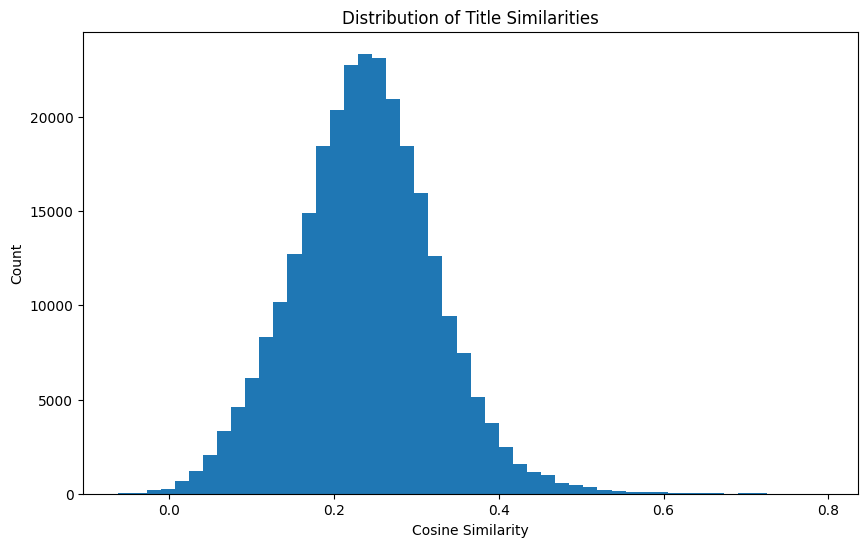

In [32]:
from sentence_transformers import SentenceTransformer
import numpy as np
from tqdm import tqdm

# Load a lightweight sentence transformer model
model = SentenceTransformer('all-MiniLM-L6-v2')  # small but effective model

# Convert titles to embeddings
df_wide_embeddings = model.encode(df_wide['P_title'].tolist(), show_progress_bar=True)
adaptive_embeddings = model.encode(adaptive_combined_df['P_title'].tolist(), show_progress_bar=True)

# Calculate cosine similarity for each pair
def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

# Calculate similarities
similarities = []
for i, emb1 in enumerate(tqdm(df_wide_embeddings)):
    for j, emb2 in enumerate(adaptive_embeddings):
        sim = cosine_similarity(emb1, emb2)
        similarities.append({
            'original_title': df_wide['P_title'].iloc[i],
            'adaptive_title': adaptive_combined_df['P_title'].iloc[j],
            'similarity': sim
        })

# Convert to DataFrame
similarity_df = pd.DataFrame(similarities)

# Show summary statistics
print("\nSimilarity Statistics:")
print(similarity_df['similarity'].describe())

# Show most similar pairs
print("\nMost Similar Questions:")
print(similarity_df.nlargest(10, 'similarity')[['original_title', 'adaptive_title', 'similarity']].round(3))

# Show least similar pairs
print("\nLeast Similar Questions:")
print(similarity_df.nsmallest(10, 'similarity')[['original_title', 'adaptive_title', 'similarity']].round(3))

# Plot distribution of similarities
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(similarity_df['similarity'], bins=50)
plt.title('Distribution of Title Similarities')
plt.xlabel('Cosine Similarity')
plt.ylabel('Count')
plt.show()

Batches:   0%|          | 0/12 [00:00<?, ?it/s]

100%|██████████| 611/611 [00:03<00:00, 202.91it/s]



Adaptive vs Random Similarity Statistics:
count    232791.000000
mean          0.344451
std           0.100472
min           0.005286
25%           0.278599
50%           0.334425
75%           0.396736
max           1.000000
Name: similarity, dtype: float64

Most Similar Questions (Adaptive vs Random):
                                           adaptive_title  \
6435    Will Bitcoin surpass $100,000 by January 1, 2026?   
37160   Will NASA successfully land humans on Mars by ...   
204743  Will Bitcoin reach $100,000 by December 31, 2025?   
204841  Will Bitcoin reach $100,000 by December 31, 2025?   
210906  Will the European Union implement a universal ...   
2007         Will Japan host the Summer Olympics in 2030?   
5909       Will Lionel Messi win the Ballon d'Or in 2025?   
6053       Will Lionel Messi win the Ballon d'Or in 2025?   
21565   Will the first human colony on Mars be establi...   
39211       Will China achieve carbon neutrality by 2060?   

                      

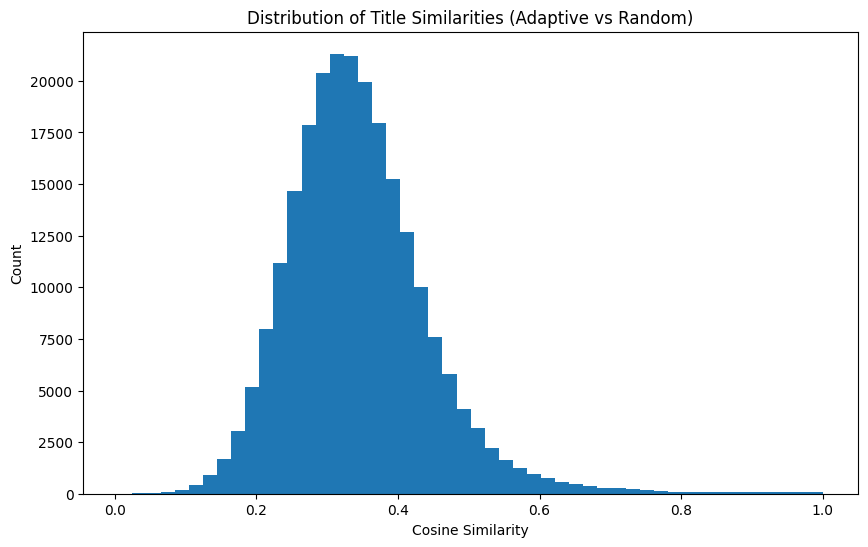

In [33]:
# Convert random titles to embeddings
random_embeddings = model.encode(random_combined_df['P_title'].tolist(), show_progress_bar=True)

# Calculate similarities between adaptive and random
adaptive_random_similarities = []
for i, emb1 in enumerate(tqdm(adaptive_embeddings)):
    for j, emb2 in enumerate(random_embeddings):
        sim = cosine_similarity(emb1, emb2)
        adaptive_random_similarities.append({
            'adaptive_title': adaptive_combined_df['P_title'].iloc[i],
            'random_title': random_combined_df['P_title'].iloc[j],
            'similarity': sim
        })

# Convert to DataFrame
adaptive_random_sim_df = pd.DataFrame(adaptive_random_similarities)

# Show summary statistics
print("\nAdaptive vs Random Similarity Statistics:")
print(adaptive_random_sim_df['similarity'].describe())

# Show most similar pairs
print("\nMost Similar Questions (Adaptive vs Random):")
print(adaptive_random_sim_df.nlargest(10, 'similarity')[['adaptive_title', 'random_title', 'similarity']].round(3))

# Show least similar pairs
print("\nLeast Similar Questions (Adaptive vs Random):")
print(adaptive_random_sim_df.nsmallest(10, 'similarity')[['adaptive_title', 'random_title', 'similarity']].round(3))

# Plot distribution
plt.figure(figsize=(10, 6))
plt.hist(adaptive_random_sim_df['similarity'], bins=50)
plt.title('Distribution of Title Similarities (Adaptive vs Random)')
plt.xlabel('Cosine Similarity')
plt.ylabel('Count')
plt.show()

100%|██████████| 381/381 [00:02<00:00, 159.42it/s]



Random vs Original Similarity Statistics:
count    171450.000000
mean          0.249661
std           0.088599
min          -0.052882
25%           0.191985
50%           0.248696
75%           0.304462
max           0.846447
Name: similarity, dtype: float64

Most Similar Questions (Random vs Original):
                                            random_title  \
167    Will FC Barcelona win the 2025 UEFA Champions ...   
417    Will FC Barcelona win the 2025 UEFA Champions ...   
179    Will FC Barcelona win the 2025 UEFA Champions ...   
433    Will FC Barcelona win the 2025 UEFA Champions ...   
55517  Will Spain win the UEFA European Championship ...   
55767  Will Spain win the UEFA European Championship ...   
91067  Will Spain win the UEFA European Championship ...   
91317  Will Spain win the UEFA European Championship ...   
43836  Will the Los Angeles Lakers win the 2025 NBA C...   
44085  Will the Los Angeles Lakers win the 2025 NBA C...   

                                 

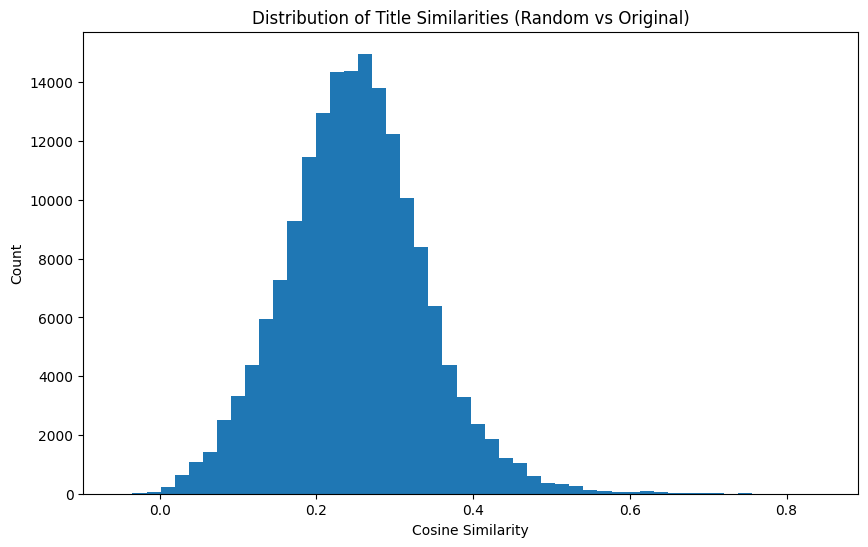

In [34]:
# We already have the embeddings for both:
# random_embeddings and df_wide_embeddings

# Calculate similarities between random and wide df
random_wide_similarities = []
for i, emb1 in enumerate(tqdm(random_embeddings)):
    for j, emb2 in enumerate(df_wide_embeddings):
        sim = cosine_similarity(emb1, emb2)
        random_wide_similarities.append({
            'random_title': random_combined_df['P_title'].iloc[i],
            'original_title': df_wide['P_title'].iloc[j],
            'similarity': sim
        })

# Convert to DataFrame
random_wide_sim_df = pd.DataFrame(random_wide_similarities)

# Show summary statistics
print("\nRandom vs Original Similarity Statistics:")
print(random_wide_sim_df['similarity'].describe())

# Show most similar pairs
print("\nMost Similar Questions (Random vs Original):")
print(random_wide_sim_df.nlargest(10, 'similarity')[['random_title', 'original_title', 'similarity']].round(3))

# Show least similar pairs
print("\nLeast Similar Questions (Random vs Original):")
print(random_wide_sim_df.nsmallest(10, 'similarity')[['random_title', 'original_title', 'similarity']].round(3))

# Plot distribution
plt.figure(figsize=(10, 6))
plt.hist(random_wide_sim_df['similarity'], bins=50)
plt.title('Distribution of Title Similarities (Random vs Original)')
plt.xlabel('Cosine Similarity')
plt.ylabel('Count')
plt.show()

In [37]:
print(stats)

                   mean    std
consistency_type              
and               0.018  0.049
andor             0.209  0.247
but               0.292  0.294
cond              0.169  0.135
consequence       0.011  0.044
expevidence       0.134  0.145
not               0.105  0.145
or                0.125  0.276
paraphrase        0.032  0.060


,sample_id,consistency_type,P_title,P_body,P_forecast,Q_title,Q_body,Q_forecast,R_title,R_body,R_forecast,S_title,S_body,S_forecast,frequentist_score
0,1,expevidence,Will Glenn Youngkin be the Republican nominee ...,This question will resolve as **Yes** if Glenn...,0.10,Will Larry Elder be the Republican nominee for...,This question will resolve as **Yes** if Larry...,0.02,"Given Larry Elder is the Republican nominee, w...",Suppose the following is true: Larry Elder is ...,0.00,Given that Larry Elder is not the Republican n...,Suppose the following is true: Larry Elder is ...,0.10,4.745362e-03
1,2,expevidence,[Metaculus] Will Joe Biden announce before Jul...,"Will Joe Biden announce before July 15, 2024 t...",0.15,Will Kamala's odds of winning increase over th...,Resolves YES if the Electoral College probabil...,0.45,Conditional on Kamala's odds of winning increa...,Suppose the following is true: Kamala Harris's...,0.15,Given Kamala's odds of winning do not increase...,Suppose the following is true: Kamala's odds o...,0.15,6.319725e-17
2,3,expevidence,Will Nikki Haley be the Republican nominee for...,This question will resolve as **Yes** if Nikki...,0.15,Will Donald Trump be the Republican nominee fo...,This question will resolve as **Yes** if Donal...,0.75,Conditional on Donald Trump being the Republic...,This question explores the scenario where Dona...,0.00,"If Donald Trump is not the Republican nominee,...",Suppose Donald Trump is not selected by the Re...,0.25,2.244789e-01
3,4,expevidence,Will Donald Trump be removed or blocked from t...,"This question will resolve as ""Yes"" if, *on* J...",0.15,Will Donald Trump be the Republican nominee fo...,This question will resolve as **Yes** if Donal...,0.75,Given Donald Trump is the Republican nominee f...,Suppose the following is true: Donald Trump is...,0.15,Given Donald Trump is not the Republican nomin...,Suppose the following is true: Donald Trump is...,0.25,5.406590e-02
4,5,expevidence,Will Donald Trump Jr. be the Republican nomine...,This question will resolve as **Yes** if Donal...,0.05,Will Asa Hutchinson be the Republican nominee ...,This question will resolve as **Yes** if Asa H...,0.02,Conditional on Asa Hutchinson being the Republ...,This question explores the scenario where Asa ...,0.00,Given Asa Hutchinson is not the Republican nom...,Suppose Asa Hutchinson is not selected by the ...,0.05,3.258730e-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
445,446,not,Will Serbia qualify for the Grand Final in Eur...,This question will resolve as **Yes** if Serbi...,0.75,Will Serbia fail to qualify for the Grand Fina...,This question will resolve as **Yes** if Serbi...,0.25,NaN,NaN,NaN,NaN,NaN,NaN,0.000000e+00
446,447,not,Will Poland qualify for the Grand Final in Eur...,This question will resolve as **Yes** if Polan...,0.55,Will Poland fail to qualify for the Grand Fina...,This question will resolve as **Yes** if Polan...,0.45,NaN,NaN,NaN,NaN,NaN,NaN,0.000000e+00
447,448,not,Will GUE/NGL hold the most seats after the 202...,This question will resolve as **Yes** if GUE/N...,0.05,Will GUE/NGL not hold the most seats after the...,This question will resolve as **Yes** if GUE/N...,0.95,NaN,NaN,NaN,NaN,NaN,NaN,0.000000e+00
448,449,not,Will Austria qualify for the Grand Final in Eu...,This question will resolve as **Yes** if Austr...,0.65,Will Austria fail to qualify for the Grand Fin...,This question will resolve as **Yes** if Austr...,0.35,NaN,NaN,NaN,NaN,NaN,NaN,0.000000e+00



Original Dataset Violations Analysis:
                  total_rows  violations  violation_rate  mean_score  \
consistency_type                                                       
and                       50           4            0.08       0.018   
andor                     50          27            0.54       0.209   
but                       50          38            0.76       0.292   
cond                      50          25            0.50       0.169   
consequence               50           3            0.06       0.011   
expevidence               50          21            0.42       0.134   
not                       50          20            0.40       0.105   
or                        50          15            0.30       0.125   
paraphrase                50           8            0.16       0.032   

                  std_score  
consistency_type             
and                   0.049  
andor                 0.247  
but                   0.294  
cond              

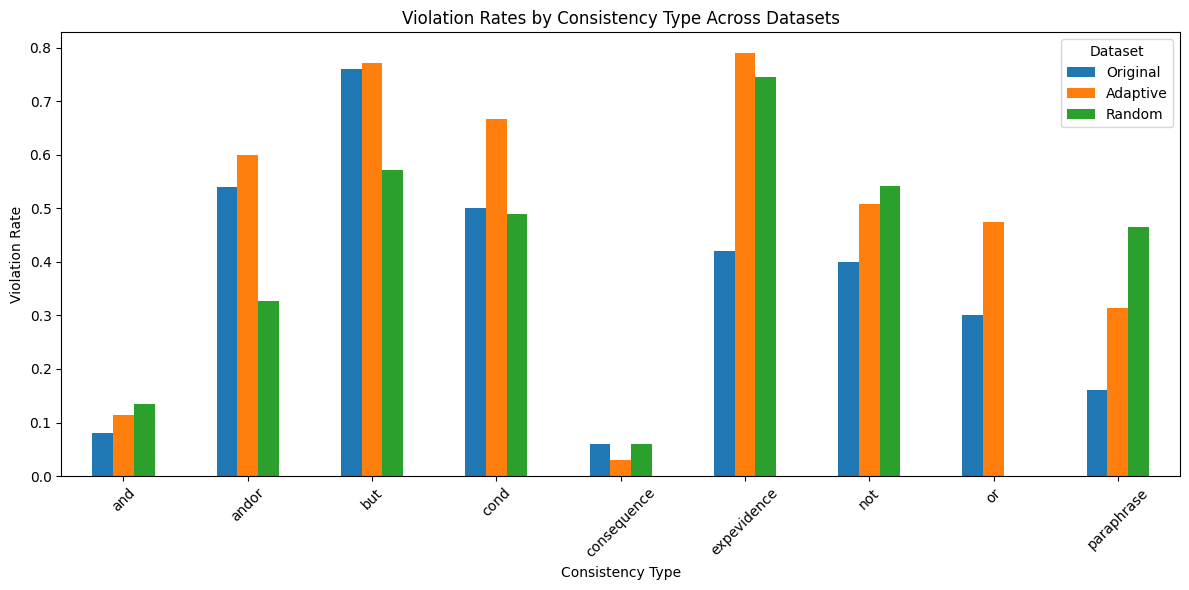


Statistical Summary:

Consistency Type: and
Threshold: 0.129


AttributeError: 'DataFrame' object has no attribute 'iteritems'

In [39]:
import pandas as pd
import numpy as np

# Define threshold parameters
sigma = 0.05
gamma = 2.58
threshold = sigma * gamma

def analyze_violations(df, name):
    """Analyze violations for a dataframe"""
    # Group by consistency_type
    grouped = df.groupby('consistency_type')['frequentist_score'].agg([
        ('total_rows', 'size'),
        ('violations', lambda x: sum(x > threshold)),
        ('violation_rate', lambda x: sum(x > threshold) / len(x)),
        ('mean_score', 'mean'),
        ('std_score', 'std')
    ]).round(3)
    
    print(f"\n{name} Violations Analysis:")
    print(grouped)
    return grouped

# Analyze each dataset
wide_violations = analyze_violations(df_wide, "Original Dataset")
adaptive_violations = analyze_violations(adaptive_combined_df, "Adaptive Dataset")
random_violations = analyze_violations(random_combined_df, "Random Dataset")

# Compare violation rates across datasets
comparison = pd.DataFrame({
    'Original': wide_violations['violation_rate'],
    'Adaptive': adaptive_violations['violation_rate'],
    'Random': random_violations['violation_rate']
})

print("\nViolation Rate Comparison Across Datasets:")
print(comparison.round(3))

# Plot comparison
import matplotlib.pyplot as plt

comparison.plot(kind='bar', figsize=(12, 6))
plt.title('Violation Rates by Consistency Type Across Datasets')
plt.xlabel('Consistency Type')
plt.ylabel('Violation Rate')
plt.xticks(rotation=45)
plt.legend(title='Dataset')
plt.tight_layout()
plt.show()

# Statistical summary
print("\nStatistical Summary:")
for ct in comparison.index:
    print(f"\nConsistency Type: {ct}")
    print(f"Threshold: {threshold:.3f}")
    for dataset, rates in comparison.iteritems():
        violations = locals()[f"{dataset.lower()}_violations"]
        print(f"{dataset}:")
        print(f"  Total samples: {violations.loc[ct, 'total_rows']}")
        print(f"  Violations: {violations.loc[ct, 'violations']}")
        print(f"  Mean score: {violations.loc[ct, 'mean_score']:.3f}")
        print(f"  Std score: {violations.loc[ct, 'std_score']:.3f}")

## o1-preview generated questions

In [27]:
logs_dir = "/Users/bprithvi/Desktop/Research Projects/Brachio/adaptive_evals/logs/o1-generated-stem-questions"


log_paths = list(Path(logs_dir).glob("*.eval"))  # Gets all .eval files
csv_paths = []

for path in log_paths:  # or log_files or eval_files
    csv_path = process_first_eval_sample(path)
    csv_paths.append(csv_path)

o1_stem_combined_df = pd.concat([pd.read_csv(path) for path in csv_paths], 
                       axis=0, 
                       ignore_index=True)

o1_stem_combined_df.rename(columns={'check_type': 'consistency_type', 'score': 'frequentist_score'}, inplace=True)

o1_stem_stats = o1_stem_combined_df.groupby('consistency_type').frequentist_score.agg(['mean', 'std']).round(3)
print(o1_stem_stats)
o1_stem_overall_stats = o1_stem_combined_df.frequentist_score.agg(['mean', 'std']).round(3)
print(o1_stem_overall_stats)

                   mean    std
consistency_type              
and               0.000  0.000
andor             0.204  0.171
but               0.345  0.403
cond              0.172  0.188
consequence       0.049  0.125
expevidence       0.361  0.453
not               0.440  0.558
or                0.161  0.269
paraphrase        0.000    NaN
mean    0.260
std     0.344
Name: frequentist_score, dtype: float64


In [29]:
sigma = 0.05
gamma = 2.58
threshold = sigma * gamma 
def analyze_consistency_violations(df):
    """Analyze violations by consistency type"""
    
    # Group by consistency type and compute metrics
    stats = df.groupby('consistency_type').agg({
        'frequentist_score': [
            ('total_rows', 'size'),
            ('violations', lambda x: sum(x > threshold)),
            ('violation_rate', lambda x: sum(x > threshold) / len(x)),
            ('mean', 'mean'),
            ('std', 'std')
        ]
    })
    
    # Flatten column names
    stats.columns = stats.columns.get_level_values(1)
    
    # Round for readability
    stats = stats.round(3)
    
    # Sort by violation rate descending
    stats = stats.sort_values('violation_rate', ascending=False)
    
    return stats

# Analyze each dataset
print("Original Dataset:")
print(analyze_consistency_violations(df_wide))
print("\nAdaptive Dataset:")
print(analyze_consistency_violations(adaptive_combined_df))
print("\nRandom Dataset:")
print(analyze_consistency_violations(random_combined_df))
print("\nO1-Stem Dataset:")
print(analyze_consistency_violations(o1_stem_combined_df))

Original Dataset:
                  total_rows  violations  violation_rate   mean    std
consistency_type                                                      
but                       50          38            0.76  0.292  0.294
andor                     50          27            0.54  0.209  0.247
cond                      50          25            0.50  0.169  0.135
expevidence               50          21            0.42  0.134  0.145
not                       50          20            0.40  0.105  0.145
or                        50          15            0.30  0.125  0.276
paraphrase                50           8            0.16  0.032  0.060
and                       50           4            0.08  0.018  0.049
consequence               50           3            0.06  0.011  0.044

Adaptive Dataset:
                  total_rows  violations  violation_rate   mean    std
consistency_type                                                      
expevidence               90          71

In [30]:
o1_stem_combined_df.frequentist_score.mean()

0.25967890015068357

In [33]:
def calculate_overall_violation_rate(df, sigma=0.05, gamma=2.58):
    """
    Calculate overall violation rate for a dataframe.
    
    Args:
        df: DataFrame with frequentist_score column
        sigma: Significance level (default 0.05)
        gamma: Confidence multiplier (default 2.58)
        
    Returns:
        Dict containing overall statistics
    """
    # Calculate threshold
    threshold = sigma * gamma
    
    # Calculate violations
    total_rows = len(df)
    violations = (df['frequentist_score'] > threshold).sum()
    violation_rate = violations / total_rows
    
    # Get mean and std of frequentist scores
    mean_score = df['frequentist_score'].mean()
    std_score = df['frequentist_score'].std()
    
    # Calculate violations by type
    type_stats = df.groupby('consistency_type').agg({
        'frequentist_score': [
            ('total', 'size'),
            ('violations', lambda x: sum(x > threshold)),
            ('violation_rate', lambda x: sum(x > threshold) / len(x)),
            ('mean', 'mean'),
            ('std', 'std')
        ]
    })
    
    # Flatten column names
    type_stats.columns = type_stats.columns.get_level_values(1)
    
    results = {
        'overall': {
            'total_questions': total_rows,
            'total_violations': violations,
            'violation_rate': violation_rate,
            'mean_score': mean_score,
            'std_score': std_score,
            'threshold': threshold
        },
        'by_type': type_stats.sort_values('violation_rate', ascending=False)
    }
    
    return results

# Example usage:
def print_violation_analysis(df, name="Dataset"):
    results = calculate_overall_violation_rate(df)
    
    print(f"\n=== {name} Violation Analysis ===")
    print(f"\nOverall Statistics:")
    print(f"Total Questions: {results['overall']['total_questions']:,}")
    print(f"Total Violations: {results['overall']['total_violations']:,}")
    print(f"Overall Violation Rate: {results['overall']['violation_rate']:.3f}")
    print(f"Mean Score: {results['overall']['mean_score']:.3f}")
    print(f"Std Score: {results['overall']['std_score']:.3f}")
    print(f"Threshold: {results['overall']['threshold']:.3f}")
    
    print("\nViolations by Consistency Type:")
    print(results['by_type'].round(3))
    
    return results

# Analyze each dataset
original_results = print_violation_analysis(df_wide, "Original Dataset")
o1_stem_results = print_violation_analysis(o1_stem_combined_df, "O1-Adaptive Dataset")
# Compare violation


=== Original Dataset Violation Analysis ===

Overall Statistics:
Total Questions: 450
Total Violations: 161
Overall Violation Rate: 0.358
Mean Score: 0.121
Std Score: 0.199
Threshold: 0.129

Violations by Consistency Type:
                  total  violations  violation_rate   mean    std
consistency_type                                                 
but                  50          38            0.76  0.292  0.294
andor                50          27            0.54  0.209  0.247
cond                 50          25            0.50  0.169  0.135
expevidence          50          21            0.42  0.134  0.145
not                  50          20            0.40  0.105  0.145
or                   50          15            0.30  0.125  0.276
paraphrase           50           8            0.16  0.032  0.060
and                  50           4            0.08  0.018  0.049
consequence          50           3            0.06  0.011  0.044

=== O1-Adaptive Dataset Violation Analysis ===

O

In [54]:
o1_stem_combined_df.to_csv("o1_stem_combined_df.csv", index=False)

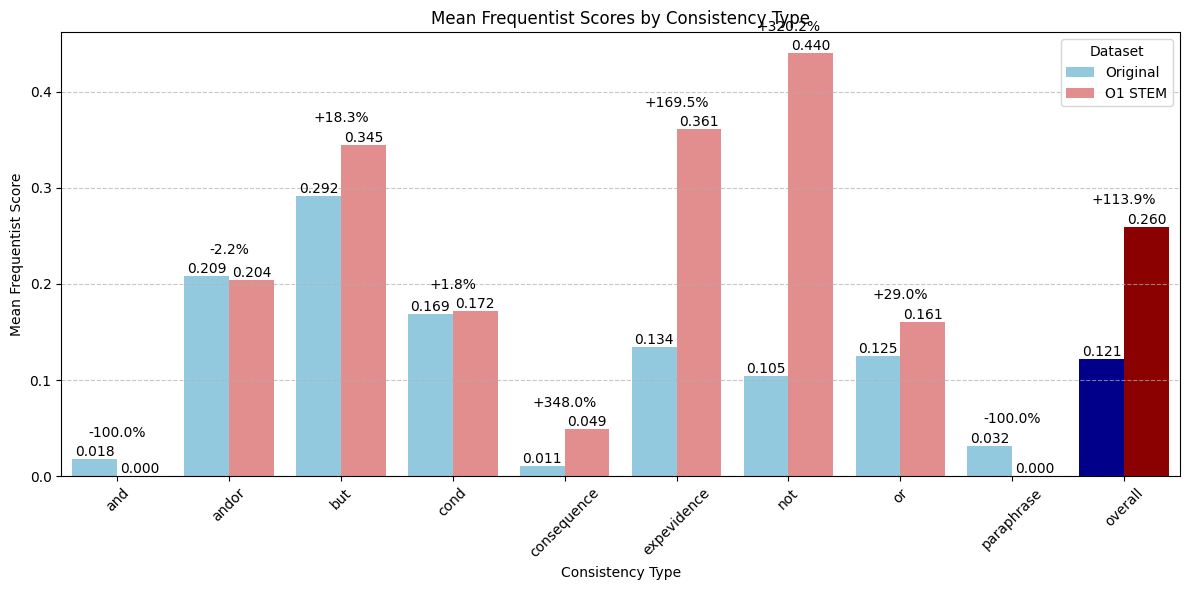

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

def plot_mean_scores_seaborn(df1, df2, name1="Original", name2="O1 STEM"):
    # Define get_means function inside
    def get_means(df):
        # Get type means
        type_means = df.groupby('consistency_type')['frequentist_score'].mean()
        # Add overall mean
        overall_mean = df['frequentist_score'].mean()
        return pd.concat([type_means, pd.Series({'overall': overall_mean})]).reset_index()
    
    # Prepare data
    means1 = get_means(df1)
    means2 = get_means(df2)
    
    # Rename columns for clarity
    means1.columns = ['consistency_type', 'frequentist_score']
    means2.columns = ['consistency_type', 'frequentist_score']
    
    # Combine data
    means1['Dataset'] = name1
    means2['Dataset'] = name2
    combined = pd.concat([means1, means2])
    
    # Create plot
    plt.figure(figsize=(12, 6))
    
    # Create the bar plot
    g = sns.barplot(data=combined, 
                x='consistency_type', 
                y='frequentist_score',
                hue='Dataset',
                palette=['skyblue', 'lightcoral'])
    
    # Highlight the overall bars with darker colors
    bars = g.patches
    for i in range(len(means1)):
        if means1['consistency_type'].iloc[i] == 'overall':
            bars[i].set_facecolor('darkblue')
            bars[i + len(means1)].set_facecolor('darkred')
    
    # Customize
    plt.xlabel('Consistency Type')
    plt.ylabel('Mean Frequentist Score')
    plt.title('Mean Frequentist Scores by Consistency Type')
    plt.xticks(rotation=45)
    
    # Add value labels on bars
    for i in range(len(means1)):
        score1 = means1['frequentist_score'].iloc[i]
        score2 = means2['frequentist_score'].iloc[i]
        
        # Add score values on bars
        plt.text(i - 0.2, score1, f'{score1:.3f}', ha='center', va='bottom')
        plt.text(i + 0.2, score2, f'{score2:.3f}', ha='center', va='bottom')
        
        # Add percentage change above bars
        pct_change = ((score2 - score1) / score1 * 100)
        plt.text(i, max(score1, score2) + 0.02,
                f'{pct_change:+.1f}%',
                ha='center', va='bottom')
    
    plt.grid(True, axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    
    return plt.gcf()

# Create the seaborn plot
fig = plot_mean_scores_seaborn(df_wide, o1_stem_combined_df)
plt.show()

/var/folders/0z/98hl6yf107q35dj2790zq94h0000gn/T/ipykernel_2348/490628399.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  type_rates = df.groupby('consistency_type').apply(
/var/folders/0z/98hl6yf107q35dj2790zq94h0000gn/T/ipykernel_2348/490628399.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  type_rates = df.groupby('consistency_type').apply(


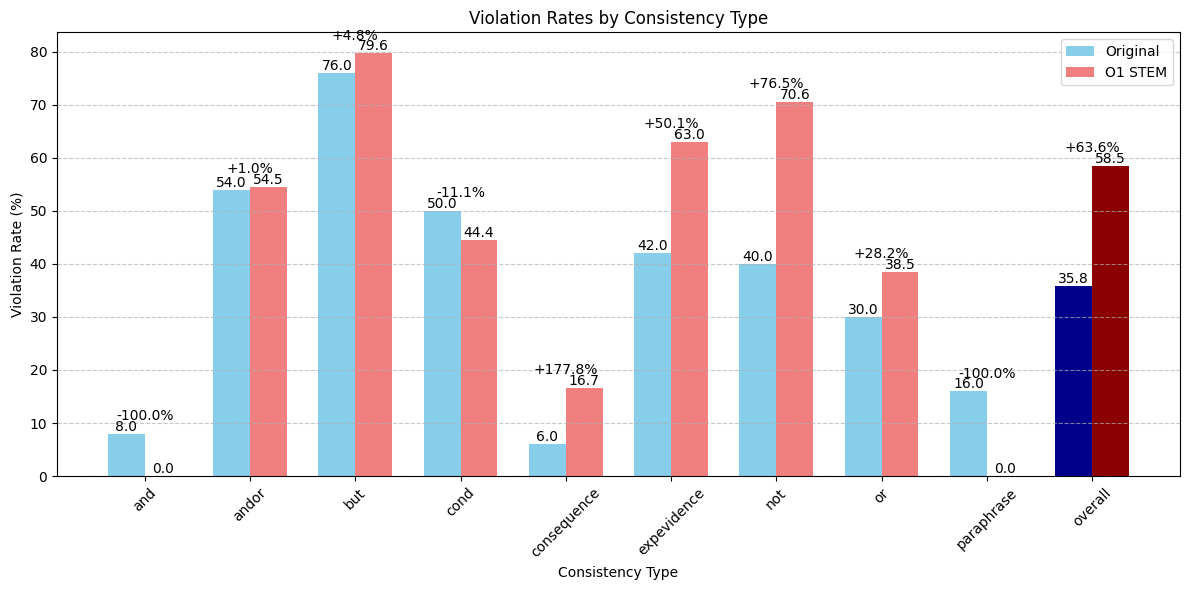

In [53]:
def plot_violation_rates_comparison(df1, df2, name1="Original", name2="O1 STEM"):
    threshold = 0.05 * 2.58
    
    def get_violation_rates(df):
        # Get type violation rates
        type_rates = df.groupby('consistency_type').apply(
            lambda x: (x['frequentist_score'] > threshold).mean() * 100
        )
        # Add overall rate
        overall_rate = (df['frequentist_score'] > threshold).mean() * 100
        return pd.concat([type_rates, pd.Series({'overall': overall_rate})]).reset_index()
    
    # Prepare data
    rates1 = get_violation_rates(df1)
    rates2 = get_violation_rates(df2)
    
    # Rename columns for clarity
    rates1.columns = ['consistency_type', 'violation_rate']
    rates2.columns = ['consistency_type', 'violation_rate']
    
    # Create figure
    plt.figure(figsize=(12, 6))
    
    # Create bars with different colors for overall
    colors1 = ['skyblue' if ct != 'overall' else 'darkblue' for ct in rates1['consistency_type']]
    colors2 = ['lightcoral' if ct != 'overall' else 'darkred' for ct in rates2['consistency_type']]
    
    # Plot bars
    x = np.arange(len(rates1))
    width = 0.35
    
    plt.bar(x - width/2, rates1['violation_rate'], width, label=name1, color=colors1)
    plt.bar(x + width/2, rates2['violation_rate'], width, label=name2, color=colors2)
    
    # Customize
    plt.xlabel('Consistency Type')
    plt.ylabel('Violation Rate (%)')
    plt.title('Violation Rates by Consistency Type')
    plt.xticks(x, rates1['consistency_type'], rotation=45)
    plt.legend()
    
    # Add value labels and percentage changes
    for i in range(len(rates1)):
        rate1 = rates1['violation_rate'].iloc[i]
        rate2 = rates2['violation_rate'].iloc[i]
        
        # Add rate values on bars
        plt.text(i - width/2, rate1, f'{rate1:.1f}', ha='center', va='bottom')
        plt.text(i + width/2, rate2, f'{rate2:.1f}', ha='center', va='bottom')
        
        # Add percentage change above bars
        pct_change = ((rate2 - rate1) / rate1 * 100)
        plt.text(i, max(rate1, rate2) + 2,
                f'{pct_change:+.1f}%',
                ha='center', va='bottom')
    
    plt.grid(True, axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    
    return plt.gcf()

# Create the plot
fig = plot_violation_rates_comparison(df_wide, o1_stem_combined_df)
plt.show()

In [43]:
def create_clean_comparison(df1, df2, name1="Original", name2="O1 STEM"):
    threshold = 0.05 * 2.58
    
    def get_stats(df):
        # Per consistency type stats
        stats = df.groupby('consistency_type').agg({
            'frequentist_score': ['size', 'mean', lambda x: sum(x > threshold) / len(x)]
        }).round(3)
        stats.columns = ['samples', 'mean_score', 'violation_rate']
        
        # Add overall
        overall = pd.DataFrame({
            'samples': [len(df)],
            'mean_score': [df['frequentist_score'].mean()],
            'violation_rate': [sum(df['frequentist_score'] > threshold) / len(df)]
        }, index=['overall'])
        
        return pd.concat([stats, overall])
    
    # Get stats for both datasets
    stats1 = get_stats(df1)
    stats2 = get_stats(df2)
    
    # Create clean comparison
    comparison = pd.DataFrame({
        f'{name1} Samples': stats1['samples'],
        f'{name2} Samples': stats2['samples'],
        f'{name1} Mean Score': stats1['mean_score'],
        f'{name2} Mean Score': stats2['mean_score'],
        'Mean Score Δ%': ((stats2['mean_score'] - stats1['mean_score']) / stats1['mean_score'] * 100).round(1),
        f'{name1} Viol%': (stats1['violation_rate'] * 100).round(1),
        f'{name2} Viol%': (stats2['violation_rate'] * 100).round(1),
        'Viol Rate Δ%': ((stats2['violation_rate'] - stats1['violation_rate']) / stats1['violation_rate'] * 100).round(1)
    })
    
    # Sort to put overall at bottom
    comparison = comparison.reindex([i for i in comparison.index if i != 'overall'] + ['overall'])
    
    return comparison

# Create and display the clean comparison
clean_comparison = create_clean_comparison(df_wide, o1_stem_combined_df)
print("\nKey Metrics Comparison")
print("=" * 100)
print(clean_comparison.to_string())


Key Metrics Comparison
             Original Samples  O1 STEM Samples  Original Mean Score  O1 STEM Mean Score  Mean Score Δ%  Original Viol%  O1 STEM Viol%  Viol Rate Δ%
and                        50                4             0.018000            0.000000         -100.0             8.0            0.0        -100.0
andor                      50               55             0.209000            0.204000           -2.4            54.0           54.5           0.9
but                        50              113             0.292000            0.345000           18.2            76.0           79.6           4.7
cond                       50               90             0.169000            0.172000            1.8            50.0           44.4         -11.2
consequence                50               12             0.011000            0.049000          345.5             6.0           16.7         178.3
expevidence                50               46             0.134000            0.361000 

## Cosine Sim

In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

def analyze_cross_dataset_similarities(df1, df2, name1="Original", name2="O1 STEM"):
    """Analyze similarities between questions across datasets"""
    model = SentenceTransformer('all-MiniLM-L6-v2')
    
    results = {}
    for ct in df1['consistency_type'].unique():
        print(f"\n{'='*80}")
        print(f"CONSISTENCY TYPE: {ct}")
        print(f"{'='*80}")
        
        # Get questions for this consistency type
        q1 = df1[df1['consistency_type'] == ct]['P_title'].tolist()
        q2 = df2[df2['consistency_type'] == ct]['P_title'].tolist()
        
        # Encode questions
        e1 = model.encode(q1)
        e2 = model.encode(q2)
        
        # Compute similarities
        similarities = cosine_similarity(e1, e2)
        
        # Calculate average similarity
        avg_sim = np.mean(similarities)
        print(f"\nAverage Cosine Similarity: {avg_sim:.3f}")
        
        # Get top 5 most similar pairs
        print("\nTop 5 Most Similar Question Pairs:")
        print('-' * 40)
        
        # Create pairs with similarities
        pairs = []
        for i in range(len(q1)):
            for j in range(len(q2)):
                pairs.append((q1[i], q2[j], similarities[i,j]))
        
        # Sort and get top 5
        pairs.sort(key=lambda x: x[2], reverse=True)
        for i, (q1, q2, sim) in enumerate(pairs[:5], 1):
            print(f"\n{i}. Similarity: {sim:.3f}")
            print(f"{name1}: {q1}")
            print(f"{name2}: {q2}")
        
        results[ct] = {
            'avg_similarity': avg_sim,
            'top_pairs': pairs[:5]
        }
    
    return results




In [46]:
similarity_results = analyze_cross_dataset_similarities(df_wide, o1_stem_combined_df)


CONSISTENCY TYPE: expevidence

Average Cosine Similarity: 0.215

Top 5 Most Similar Question Pairs:
----------------------------------------

1. Similarity: 0.730
Original: At the Paris Summer Olympics in 2024, will the men's 100m dash winning time break the Olympic record of 9.63s?
O1 STEM: Will an athlete break the 100m sprint record by running under 8 seconds by 2100?

2. Similarity: 0.594
Original: Will INC form the government after the next Indian general election in 2024?
O1 STEM: Will a completely new form of government be implemented in a major country by 2050?

3. Similarity: 0.521
Original: Will a swimmer win the most gold medals at the 2024 Paris Olympics?
O1 STEM: Will an athlete break the 100m sprint record by running under 8 seconds by 2100?

4. Similarity: 0.515
Original: Will INC form the government after the next Indian general election in 2024?
O1 STEM: Will a global governance body be established with legislative powers over sovereign nations by 2045?

5. Similarity

In [49]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

def analyze_potential_duplicates(df, similarity_threshold=0.85):
    """Analyze potential duplicates within each consistency type"""
    model = SentenceTransformer('all-MiniLM-L6-v2')
    
    results = {}
    print("\nPotential Duplicates Analysis (Cosine Similarity > 0.85)")
    print("=" * 80)
    
    for ct in df['consistency_type'].unique():
        # Get questions for this consistency type
        group = df[df['consistency_type'] == ct]
        titles = group['P_title'].tolist()
        
        if len(titles) < 2:  # Skip if only one question
            continue
            
        # Encode titles
        embeddings = model.encode(titles)
        
        # Compute similarities
        similarities = cosine_similarity(embeddings)
        
        # Find potential duplicates (excluding self-similarity)
        potential_dupes = []
        for i in range(len(titles)):
            for j in range(i + 1, len(titles)):  # only upper triangle
                if similarities[i, j] > similarity_threshold:
                    potential_dupes.append((titles[i], titles[j], similarities[i, j]))
        
        # Calculate duplicate percentage
        total_pairs = (len(titles) * (len(titles) - 1)) / 2  # number of unique pairs
        duplicate_pairs = len(potential_dupes)
        duplicate_percentage = (duplicate_pairs / total_pairs * 100) if total_pairs > 0 else 0
        
        results[ct] = {
            'total_questions': len(titles),
            'total_pairs': int(total_pairs),
            'duplicate_pairs': duplicate_pairs,
            'duplicate_percentage': duplicate_percentage,
            'duplicate_examples': potential_dupes
        }
        
        # Print results for this consistency type
        print(f"\nConsistency Type: {ct}")
        print(f"Total Questions: {len(titles)}")
        print(f"Potential Duplicate Pairs: {duplicate_pairs}/{int(total_pairs)} ({duplicate_percentage:.1f}%)")
        
        if potential_dupes:
            print("\nExample Similar Pairs:")
            for i, (q1, q2, sim) in enumerate(potential_dupes[:3], 1):  # Show top 3 examples
                print(f"\n{i}. Similarity: {sim:.3f}")
                print(f"Q1: {q1}")
                print(f"Q2: {q2}")
    
    # Create summary DataFrame
    summary = pd.DataFrame({
        'Total Questions': [d['total_questions'] for d in results.values()],
        'Total Pairs': [d['total_pairs'] for d in results.values()],
        'Duplicate Pairs': [d['duplicate_pairs'] for d in results.values()],
        'Duplicate %': [d['duplicate_percentage'] for d in results.values()]
    }, index=results.keys())
    
    print("\nSummary of Duplicate Analysis")
    print("=" * 80)
    print(summary.sort_values('Duplicate %', ascending=False).round(1))
    
    return results

# Run the analysis on O1 dataset
duplicate_analysis = analyze_potential_duplicates(o1_stem_combined_df)


Potential Duplicates Analysis (Cosine Similarity > 0.85)

Consistency Type: andor
Total Questions: 55
Potential Duplicate Pairs: 1/1485 (0.1%)

Example Similar Pairs:

1. Similarity: 0.874
Q1: Will a new religious movement surpass 100 million global adherents by 2035?
Q2: Will a New Major Religion Emerge with Over 100 Million Followers by 2035?

Consistency Type: but
Total Questions: 113
Potential Duplicate Pairs: 8/6328 (0.1%)

Example Similar Pairs:

1. Similarity: 0.925
Q1: Will a human brain be successfully uploaded and emulated digitally by 2040?
Q2: Will a Human Brain Be Successfully Uploaded to a Digital Substrate by 2040?

2. Similarity: 0.902
Q1: Will a functional quantum computer breach 4096-bit RSA encryption by 2035?
Q2: Will quantum computers break 2048-bit RSA encryption by 2030?

3. Similarity: 0.913
Q1: Will climate engineering techniques reduce global temperatures by 1°C by 2050?
Q2: Will climate engineering techniques be deployed on a large scale to lower global temp

## Save Questions to CSV

In [60]:
def process_first_eval_sample_with_body(log_path: str) -> str:
    """
    Process the first eval sample from a log file and convert it to CSV format.
    Combines title and body into question fields for P, Q, R, S.
    
    Args:
        log_path: Path to the eval log file
    
    Returns:
        str: Path to the generated CSV file
    """
    # Read the log file using read_eval_log
    eval_log = read_eval_log(log_path)
    if not eval_log.samples:
        raise ValueError("No samples found in eval log")
    
    # Get first sample
    sample = eval_log.samples[0]
    consistency_checks = sample.metadata.get('consistency_checks', {})
    
    # Prepare CSV data
    csv_rows = []
    headers = ['check_type', 
               'P_question', 'P_forecast', 
               'Q_question', 'Q_forecast', 
               'R_question', 'R_forecast',
               'S_question', 'S_forecast',
               'score']
    
    def combine_title_body(item):
        """Helper function to combine title and body"""
        title = item.get('title', '')
        body = item.get('body', '')
        if title and body:
            return f"{title}\n\n{body}"
        return title or body or ''
    
    # Process each type of consistency check
    for check_type, checks in consistency_checks.items():
        if not isinstance(checks, list):
            continue
            
        for check in checks:
            row = {
                'check_type': check_type,
                'P_question': combine_title_body(check['P']),
                'P_forecast': check['P'].get('forecast', ''),
                'Q_question': combine_title_body(check['Q']),
                'Q_forecast': check['Q'].get('forecast', ''),
                'R_question': combine_title_body(check.get('R', {})),
                'R_forecast': check.get('R', {}).get('forecast', ''),
                'S_question': combine_title_body(check.get('S', {})),
                'S_forecast': check.get('S', {}).get('forecast', ''),
                'score': check.get('score', '')
            }
            csv_rows.append(row)
    
    # Generate output filename
    output_dir = os.path.dirname(log_path)
    base_name = os.path.splitext(os.path.basename(log_path))[0]
    output_path = os.path.join(output_dir, f"{base_name}_processed.csv")
    
    # Write to CSV
    with open(output_path, 'w', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=headers)
        writer.writeheader()
        writer.writerows(csv_rows)
    
    return output_path

In [61]:
logs_dir = "/Users/bprithvi/Desktop/Research Projects/Brachio/adaptive_evals/logs/o1-generated-stem-questions"


log_paths = list(Path(logs_dir).glob("*.eval"))  # Gets all .eval files
csv_paths = []

for path in log_paths:  # or log_files or eval_files
    csv_path = process_first_eval_sample_with_body(path)
    csv_paths.append(csv_path)

o1_stem_combined_df = pd.concat([pd.read_csv(path) for path in csv_paths], 
                       axis=0, 
                       ignore_index=True)

o1_stem_combined_df.rename(columns={'check_type': 'consistency_type', 'score': 'frequentist_score'}, inplace=True)

o1_stem_stats = o1_stem_combined_df.groupby('consistency_type').frequentist_score.agg(['mean', 'std']).round(3)
print(o1_stem_stats)
o1_stem_overall_stats = o1_stem_combined_df.frequentist_score.agg(['mean', 'std']).round(3)
print(o1_stem_overall_stats)

                   mean    std
consistency_type              
and               0.000  0.000
andor             0.204  0.171
but               0.345  0.403
cond              0.172  0.188
consequence       0.049  0.125
expevidence       0.361  0.453
not               0.440  0.558
or                0.161  0.269
paraphrase        0.000    NaN
mean    0.260
std     0.344
Name: frequentist_score, dtype: float64


In [62]:
o1_stem_combined_df.to_csv("o1_adaptive_questions.csv", index=False)